# Survival statistics — LifeSphere TCGA (Neo4j)

Extracts and summarizes the live `lifesphere` graph: schema shape, survival-endpoint censoring, per-Subject fan-out, Study-level imbalance, and a 5-year mortality horizon feasibility check. Companion to `docs/research/gl-gnn-survival-methods.md` — this notebook runs (a subset of) the same queries directly from Python instead of `cypher-shell`.

Read-only. Requires: `neo4j`, `python-dotenv`, `pandas`, `matplotlib`
(`pip install neo4j python-dotenv pandas matplotlib`).

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from neo4j import GraphDatabase

load_dotenv(find_dotenv())  # walks up from notebooks/ to the repo-root .env

URI = os.environ["NEO4J_URI"]
USER = os.environ["NEO4J_USER"]
PASSWORD = os.environ["NEO4J_PASSWORD"]
DATABASE = os.environ.get("NEO4J_DATABASE", "lifesphere")

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))
driver.verify_connectivity()


def run_query(query: str, **params) -> pd.DataFrame:
    with driver.session(database=DATABASE) as session:
        return pd.DataFrame([r.data() for r in session.run(query, **params)])

## Schema overview

Labels, relationship types, and node counts.

In [2]:
labels = run_query("CALL db.labels() YIELD label RETURN label ORDER BY label")
rel_types = run_query(
    "CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType ORDER BY relationshipType"
)

node_counts = run_query(
    "MATCH (n) RETURN labels(n)[0] AS label, count(*) AS n ORDER BY n DESC"
)
print(f"{len(labels)} labels, {len(rel_types)} relationship types")
node_counts

10 labels, 9 relationship types


,label,n
0,Sample,165261
1,Intervention,55832
2,Survival,37063
3,Diagnosis,18843
4,PathologyDetail,14366
5,Subject,11428
6,PhenotypeObservation,4500
7,Condition,173
8,Study,33
9,Program,1


## Survival endpoint distributions

Event/censoring counts and time-to-event (days) percentiles per endpoint (OS / PFI / DSS / DFI). `eventOccurred` and `timeToEventDays` are stored as Neo4j strings — cast explicitly.

In [3]:
survival_dist = run_query(
    """
    MATCH (s:Survival)
    WITH s.survivalType AS endpoint,
         toInteger(s.eventOccurred) AS event,
         toInteger(s.timeToEventDays) AS t
    RETURN endpoint, event, count(*) AS n,
           min(t) AS min_t, percentileDisc(t, 0.5) AS median_t, max(t) AS max_t
    ORDER BY endpoint, event
    """
)
survival_dist

,endpoint,event,n,min_t,median_t,max_t
0,DFI,0,4284,0,792,8562
1,DFI,1,1099,0,469,6387
2,DSS,0,7825,0,784,11259
3,DSS,1,2435,0,557,10877
4,OS,0,7291,0,796,11259
5,OS,1,3514,0,549,10877
6,PFI,0,6718,0,725,11224
7,PFI,1,3897,0,360,10341


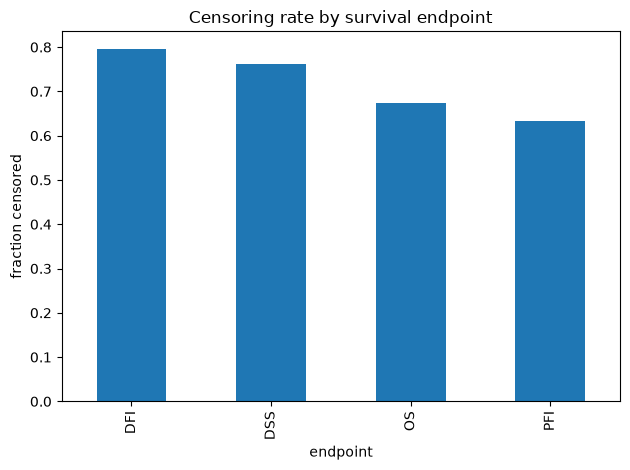

In [4]:
censoring = survival_dist.pivot(index="endpoint", columns="event", values="n")
censoring = censoring.rename(columns={0: "censored", 1: "event"})
censoring["censoring_rate"] = censoring["censored"] / (censoring["censored"] + censoring["event"])

censoring["censoring_rate"].plot(kind="bar", title="Censoring rate by survival endpoint", ylabel="fraction censored")
plt.tight_layout()
plt.show()

## Per-Subject fan-out

How many Diagnosis / Sample nodes hang off each Subject — relevant to whether a per-Subject subgraph has real variable-cardinality structure for a GNN to exploit.

In [5]:
fanout = run_query(
    """
    MATCH (sub:Subject)
    OPTIONAL MATCH (sub)-[:HAS_DIAGNOSIS]->(d:Diagnosis)
    OPTIONAL MATCH (sub)-[:PROVIDED_SAMPLE]->(sm:Sample)
    RETURN sub.subjectId AS subjectId, count(DISTINCT d) AS n_diagnosis, count(DISTINCT sm) AS n_sample
    """
)
fanout[["n_diagnosis", "n_sample"]].describe(percentiles=[0.5, 0.9, 0.99])

,n_diagnosis,n_sample
count,11428.000000,11428.000000
mean,1.648845,14.461061
std,1.284430,6.349300
min,0.000000,0.000000
50%,1.000000,13.000000
90%,3.000000,24.000000
99%,7.000000,35.000000
max,28.000000,113.000000


## Study-level class imbalance

Subject counts per TCGA Study.

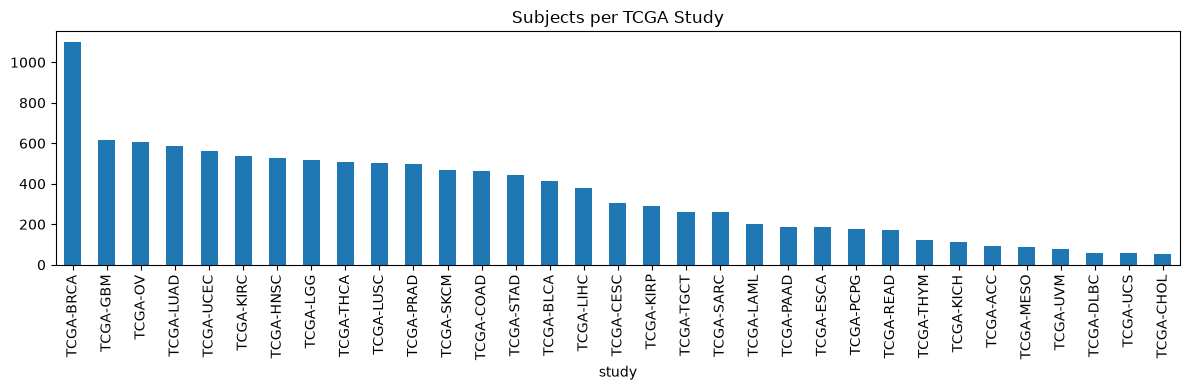

In [6]:
study_counts = run_query(
    """
    MATCH (st:Study)-[:HAS_SUBJECT]->(sub:Subject)
    RETURN st.studyId AS study, count(sub) AS n_subjects
    ORDER BY n_subjects DESC
    """
)
study_counts.plot(x="study", y="n_subjects", kind="bar", figsize=(12, 4), legend=False, title="Subjects per TCGA Study")
plt.tight_layout()
plt.show()

## 5-year mortality horizon (binary-classification feasibility)

For a fixed-horizon binary mortality label: `died_within_horizon` (event within 5y) vs. `survived_past_horizon` (known alive/event-free at 5y) vs. `excluded_censored_early` (last follow-up before 5y — 5-year status unknown, dropped from the usable cohort).

In [7]:
HORIZON_DAYS = 5 * 365

horizon = run_query(
    """
    MATCH (s:Survival)
    WITH s.survivalType AS endpoint,
         toInteger(s.eventOccurred) AS event,
         toInteger(s.timeToEventDays) AS t
    WITH endpoint,
         CASE
           WHEN event = 1 AND t <= $horizon THEN 'died_within_horizon'
           WHEN t >= $horizon THEN 'survived_past_horizon'
           ELSE 'excluded_censored_early'
         END AS bucket
    RETURN endpoint, bucket, count(*) AS n
    ORDER BY endpoint, bucket
    """,
    horizon=HORIZON_DAYS,
)

horizon_pivot = horizon.pivot(index="endpoint", columns="bucket", values="n").fillna(0)
horizon_pivot["total"] = horizon_pivot.sum(axis=1)
horizon_pivot["pct_excluded"] = (horizon_pivot["excluded_censored_early"] / horizon_pivot["total"] * 100).round(1)
horizon_pivot

bucket,died_within_horizon,excluded_censored_early,survived_past_horizon,total,pct_excluded
endpoint,,,,,
DFI,1044,3510,829,5383,65.2
DSS,2198,6370,1692,10260,62.1
OS,3122,5922,1761,10805,54.8
PFI,3696,5616,1303,10615,52.9


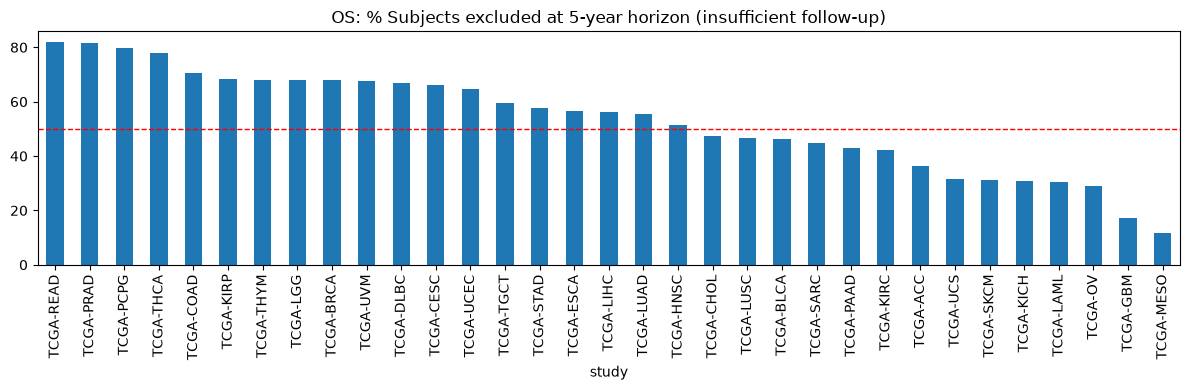

In [8]:
study_exclusion = run_query(
    """
    MATCH (st:Study)-[:HAS_SUBJECT]->(sub:Subject)-[:HAS_SURVIVAL_RECORD]->(s:Survival)
    WHERE s.survivalType = 'OS'
    WITH st.studyId AS study,
         toInteger(s.eventOccurred) AS event,
         toInteger(s.timeToEventDays) AS t
    WITH study,
         CASE WHEN event = 1 AND t <= $horizon THEN 0
              WHEN t >= $horizon THEN 0
              ELSE 1 END AS excluded
    RETURN study, count(*) AS total, sum(excluded) AS excluded
    """,
    horizon=HORIZON_DAYS,
)
study_exclusion["pct_excluded"] = (study_exclusion["excluded"] / study_exclusion["total"] * 100).round(1)
study_exclusion = study_exclusion.sort_values("pct_excluded", ascending=False)

study_exclusion.plot(
    x="study", y="pct_excluded", kind="bar", figsize=(12, 4), legend=False,
    title="OS: % Subjects excluded at 5-year horizon (insufficient follow-up)",
)
plt.axhline(50, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [9]:
driver.close()

## Notes

- Full writeup and citations: `docs/research/gl-gnn-survival-methods.md`.
- The 5-year horizon materially shrinks and reshapes the usable cohort (more so for some Studies than others) — factor that into any binary-mortality vs. censoring-aware (Cox / discrete-time) modeling decision.